### **Langkah 1: Pengambilan dan Pemuatan Data**

Bagian ini bertanggung jawab untuk menginstal pustaka yang diperlukan, mengunduh dataset dari Kaggle, dan memuatnya ke dalam Pandas DataFrame untuk analisis lebih lanjut.

In [ ]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn -q

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Mengunduh dataset dari Kaggle...")

path = kagglehub.dataset_download("quantbruce/real-estate-price-prediction")
print("Path to dataset files: ", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

df = pd.read_csv(csv_path)

display(df.head())

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'real-estate-price-prediction' dataset.
Path to dataset files:  /kaggle/input/real-estate-price-prediction


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### **Langkah 2: Analisis Distribusi Harga Rumah**

Pada langkah ini, kita akan membuat histogram untuk memvisualisasikan distribusi harga rumah per unit area (`Y house price of unit area`) dalam dataset. Ini membantu kita memahami sebaran data harga dan melihat apakah ada kemiringan (skewness) dalam distribusinya.

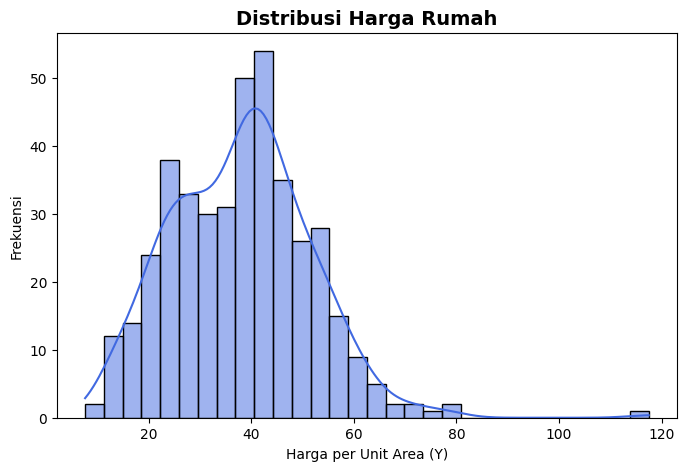

Nilai Skewness (Kemiringan):  0.5998525842660576


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Y house price of unit area'], kde=True, bins=30, color='royalblue')
plt.title('Distribusi Harga Rumah', fontsize=14, fontweight='bold')
plt.xlabel('Harga per Unit Area (Y)')
plt.ylabel('Frekuensi')
plt.show()

print("Nilai Skewness (Kemiringan): ", df['Y house price of unit area'].skew())

### **Langkah 3: Analisis Korelasi dengan Heatmap**

Selanjutnya, kita akan menghitung matriks korelasi antar semua fitur dalam dataset. Matriks ini kemudian divisualisasikan menggunakan heatmap, yang memungkinkan kita untuk dengan mudah melihat hubungan dan kekuatan korelasi antara setiap pasangan variabel. Warna yang lebih gelap atau lebih terang menunjukkan korelasi yang lebih kuat.

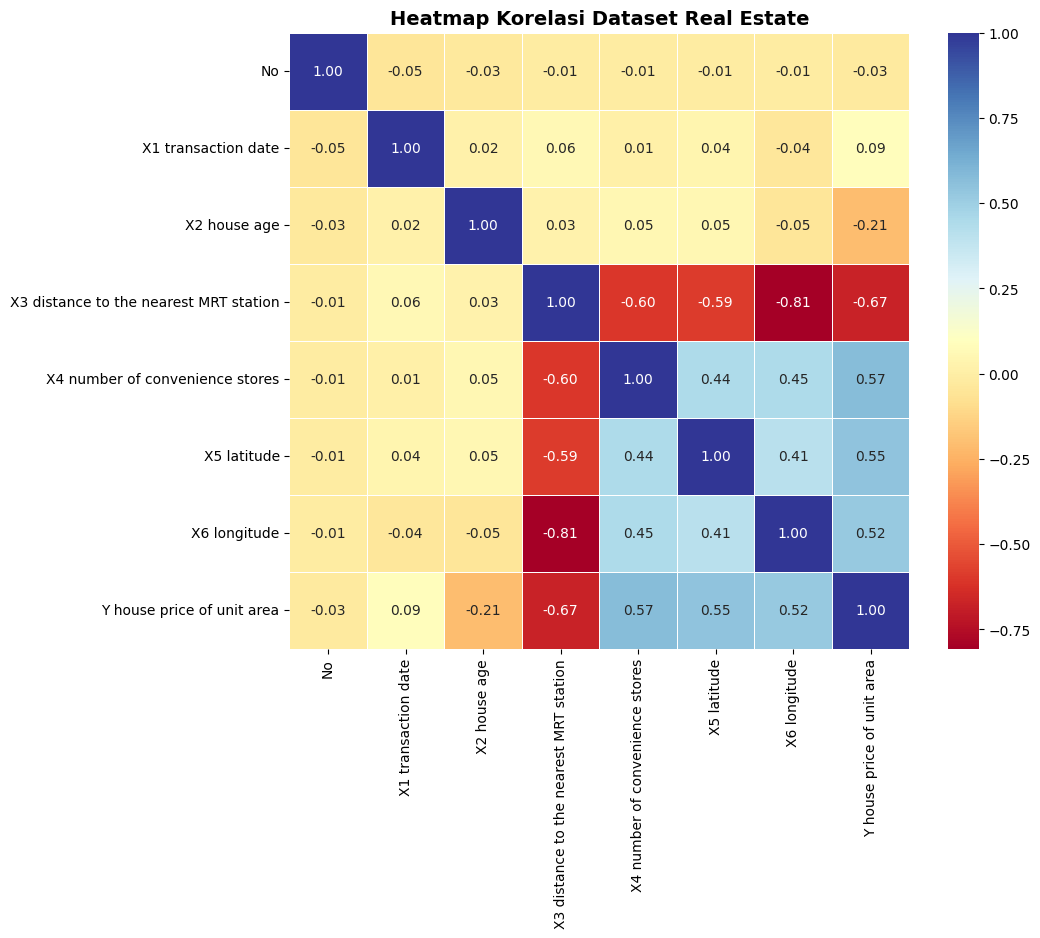

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Dataset Real Estate', fontsize=14, fontweight='bold')
plt.show()

### **Langkah 4: Pembagian Data Latih dan Data Uji**

Sebelum melatih model, dataset perlu dibagi menjadi dua bagian: data pelatihan (training data) dan data pengujian (testing data). Data pelatihan digunakan untuk mengajarkan model, sementara data pengujian digunakan untuk mengevaluasi seberapa baik kinerja model pada data yang belum pernah dilihat sebelumnya. Kolom 'No' (nomor identifikasi) dan 'Y house price of unit area' (target) akan dipisahkan dari fitur lainnya.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['No', 'Y house price of unit area'])
y = df['Y house price of unit area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total data pelatihan: {X_train.shape[0]} baris")
print(f"Total data pengujian: {X_test.shape[0]} baris")

Total data pelatihan: 331 baris
Total data pengujian: 83 baris


### **Langkah 5: Pelatihan Model Regresi Linear**

Pada langkah ini, kita akan mengimplementasikan model Regresi Linear. Model ini akan dilatih menggunakan data pelatihan untuk belajar hubungan antara fitur-fitur input dan harga rumah. Setelah pelatihan, model akan digunakan untuk membuat prediksi pada data pengujian.

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print("Proses training dan inferensi selesai!")

Proses training dan inferensi selesai!


### **Langkah 6: Evaluasi Model Regresi Linear**

Setelah model Regresi Linear selesai dilatih dan membuat prediksi, kita perlu mengevaluasi seberapa baik kinerjanya. Metrik evaluasi seperti Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), dan R-squared (R2) akan dihitung. Selain itu, visualisasi akan dibuat untuk membandingkan harga asli dengan harga prediksi model.

Mean Absolute Error (MAE): 5.31
Root Mean Squared Error (RMSE): 7.31
R-squared (R2) Score: 0.68


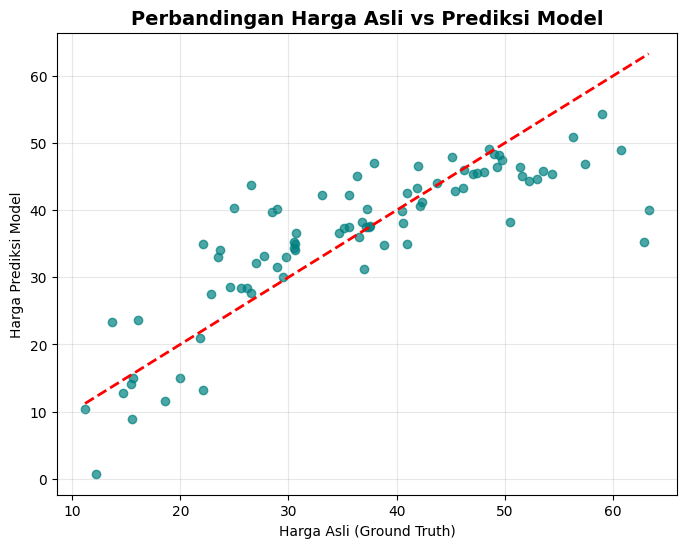

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Perbandingan Harga Asli vs Prediksi Model', fontsize=14, fontweight='bold')
plt.xlabel('Harga Asli (Ground Truth)')
plt.ylabel('Harga Prediksi Model')
plt.grid(True, alpha=0.3)
plt.show()

### **Langkah 7: Pelatihan Model Random Forest Regressor**

Sebagai alternatif, kita juga akan melatih model Regressor Random Forest. Random Forest adalah model ensemble yang biasanya menawarkan performa lebih baik dibandingkan Regresi Linear, terutama untuk data yang kompleks. Model ini akan dilatih dengan data pelatihan yang sama dan kemudian digunakan untuk membuat prediksi pada data pengujian.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# model Random Forest
# n_estimators=100, menggunakan 100 'pohon' keputusan

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Training Process
model_rf.fit(X_train, y_train)

# Melakukan prediksi dari data pengujian
y_pred_rf = model_rf.predict(X_test)

print("Proses training Random Forest selesai!")

Proses training Random Forest selesai!


### **Langkah 8: Perbandingan Performa Model**

Setelah melatih kedua model (Regresi Linear dan Random Forest), langkah ini membandingkan kinerja keduanya menggunakan metrik evaluasi yang sama (MAE, RMSE, R2). Hasil perbandingan akan ditampilkan dalam bentuk tabel dan grafik batang agar mudah dilihat model mana yang memiliki performa lebih baik.

,Metrik,Linear Regression,Random Forest
0,MAE (Lebih rendah lebih baik),5.305356,3.959689
1,RMSE (Lebih rendah lebih baik),7.314754,5.693072
2,R-Squared (Lebih tinggi lebih baik),0.681058,0.806801


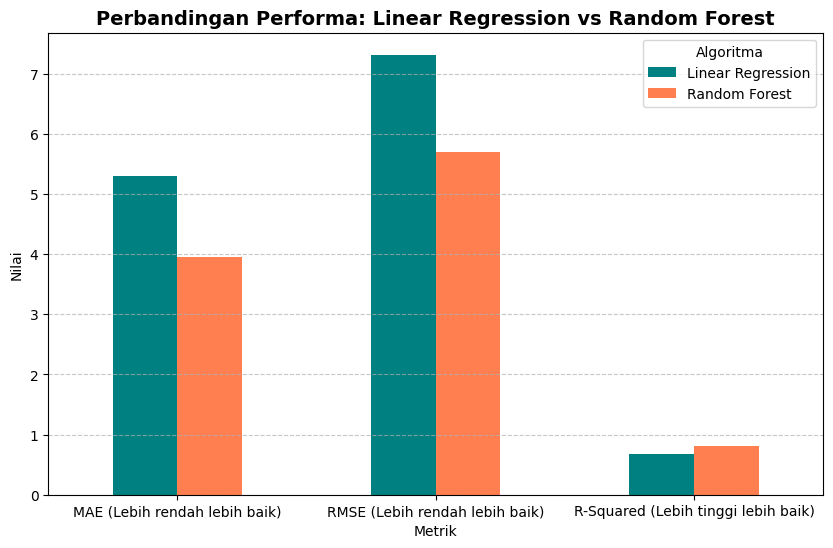

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

comparison_df = pd.DataFrame({
    'Metrik': ['MAE (Lebih rendah lebih baik)', 'RMSE (Lebih rendah lebih baik)', 'R-Squared (Lebih tinggi lebih baik)'],
    'Linear Regression': [mae, rmse, r2],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
})

display(comparison_df)

comparison_df.set_index('Metrik').plot(kind='bar', figsize=(10, 6), color=['teal', 'coral'])
plt.title('Perbandingan Performa: Linear Regression vs Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Nilai')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Algoritma')
plt.show()

### **Langkah 9: Visualisasi Pola Prediksi Model**

Untuk mendapatkan pemahaman visual yang lebih dalam tentang kinerja kedua model, langkah ini membuat dua scatter plot. Setiap plot akan menampilkan perbandingan antara harga asli dan harga prediksi untuk masing-masing model, bersama dengan garis ideal (garis merah putus-putus) di mana harga asli sama dengan harga prediksi. Ini membantu kita melihat pola sebaran prediksi dan seberapa dekat model mendekati garis ideal.

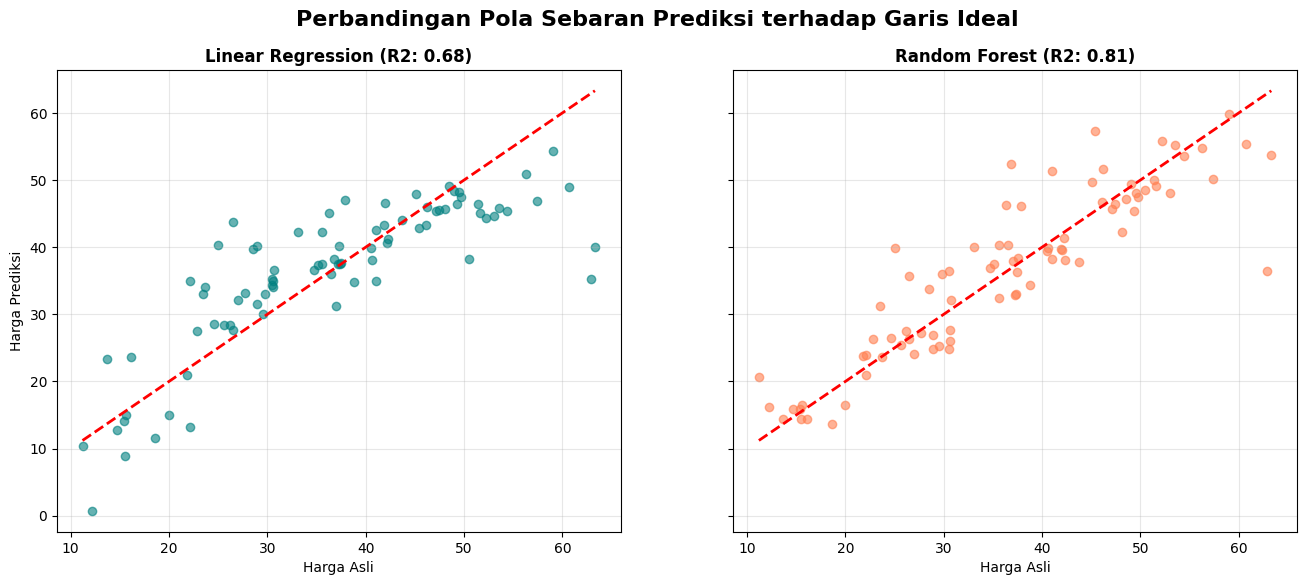

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].scatter(y_test, y_pred, alpha=0.6, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R2: {r2:.2f})', fontweight='bold')
axes[0].set_xlabel('Harga Asli')
axes[0].set_ylabel('Harga Prediksi')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='coral')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest (R2: {r2_rf:.2f})', fontweight='bold')
axes[1].set_xlabel('Harga Asli')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Pola Sebaran Prediksi terhadap Garis Ideal', fontsize=16, fontweight='bold')
plt.show()